In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_NS_config, hash_configs
import arviz as az
from jaxns.utils import load_results
from jaxns import resample
import jax
import tensorflow_probability as tfd
from matplotlib.collections import LineCollection


c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\jaxns\internals\mixed_precision.py:14: UserWarning: JAX x64 is not enabled. Setting it now. Check for errors.
  warnings.warn("JAX x64 is not enabled. Setting it now. Check for errors.")
INFO:2026-03-09 14:27:15,610:jax._src.xla_bridge:867: Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.




In [2]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [3]:
data = get_data()
config = get_NS_config()
# c14_config = get_NS_config(c14 = True)

hash = hash_configs(config, data)
# c14_hash = hash_configs(c14_config, data)
output_dir = f"output/sd_{config["sd"]}/{hash}"
print(output_dir)
# c14_output_dir = f"output/{c14_hash}"

output/sd_50/089f2ff529


In [4]:
# c14_results = load_results(f"output/{c14_hash}/results_c14.json")
results = load_results(f"{output_dir}/results_d18o.json")
# results = load_results(f"output/results_less_data_onlyc14.json")

In [5]:
# flattened = np.load(r"C:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_c14_normal\output\68831df8d5\samples.npy")[0, 1000:, :]

# key = jax.random.PRNGKey(config["sd"])
# key, subkey = jax.random.split(key)

# sigma_x = np.cov(flattened, rowvar=False)
# mu_x = np.mean(flattened, axis = 0)
# L_w = np.linalg.cholesky(sigma_x + np.eye(data["N"]) * 1e-6)

samples = np.array(results.samples['sed_rates'])
# samples = mu_x[None, :] + np.dot(z_samples, L_w)

# c14_samples = np.array(c14_results.samples['sed_rates'])

# samples = samples[::100, :]

In [ ]:
print(np.shape(samples))
print(results.ESS)
print(results.log_efficiency)

(1000000, 50)
62863.70979545562
-8.578526665372916


In [7]:
key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)
posterior_samples = resample(
    subkey,
    results.samples,
    results.log_dp_mean,
    S=int(results.ESS),
    replace = True
)

posterior_samples= np.array(posterior_samples['sed_rates'])
# posterior_samples = mu_x[None, :] + np.dot(z_samples, L_w)

# c14_posterior_samples = resample(
#     subkey,
#     c14_results.samples,
#     c14_results.log_dp_mean,
#     S=len(c14_samples)
# )

# c14_posterior_samples= np.array(c14_posterior_samples['sed_rates'])

del results

import gc
gc.collect()

0

In [8]:
d18O_indices = []
for i in range(len(data["d18od"])):
    index = get_index(data["N"], data["cs"], data["d18od"], i)
    d18O_indices.append(index)
c14_indices = []
for i in range(len(data["c14d"])):
    index = get_index(data["N"], data["cs"], data["c14d"], i)
    c14_indices.append(index)

In [9]:
def interpolate_D18O(
    D18O_times,
    D18O_reference,
    D18O_reference_times
):

    num_D18O_depths = len(D18O_times)
    num_D18O_reference_times = len(D18O_reference_times)

    D18O_reference_interp = np.zeros(num_D18O_depths)
    D18O_interp_derivative = np.zeros(num_D18O_depths)

    for i in range(num_D18O_depths):
        # Equivalent to binary_search(...) - 1
        index = np.searchsorted(D18O_reference_times, D18O_times[i]) - 1

        # Safety clamp (C code assumes valid indices)
        index = np.clip(index, 0, num_D18O_reference_times - 2)

        t0 = D18O_reference_times[index]
        t1 = D18O_reference_times[index + 1]
        y0 = D18O_reference[index]
        y1 = D18O_reference[index + 1]
        t = D18O_times[i]

        dt = t1 - t0
        dy = y1 - y0

        slope = dy / dt
        D18O_interp_derivative[i] = slope
        D18O_reference_interp[i] = y0 + slope * (t - t0)

    return D18O_reference_interp

In [10]:
def energy_function(sed_rates):
    # prior = np.sum(-config["a"]*np.log(sed_rates) + config["b"]*sed_rates)

    c14_conditional = np.sum((data["c14"] - expected_ages(data["N"], data["dc"], data["cs"], data["th"], data["nc14d"], data["c14d"], sed_rates, c14_indices))**2/(2 * data["c14s"]**2))

    expected_d18O_ages = expected_ages(data["N"], data["dc"], data["cs"], data["th"], data["nd18o"], data["d18od"], sed_rates, d18O_indices)
    d18O_reference_interp = interpolate_D18O(expected_d18O_ages, data["d18or"], data["d18ort"])
    d18O_conditional = np.sum((data["d18o"] - d18O_reference_interp)**2/(2 * data["d18os"]**2))

    # print(f"prior : {prior}")
    # print(f"c14 cond: {c14_conditional}")
    # print(f"d18O cond: {d18O_conditional}")
    return c14_conditional + d18O_conditional #prior + 

In [11]:
depths = np.sort(np.hstack((0, data["d18od"])))
ages = np.flip(np.hstack((data["th"], data["d18ota"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["th"]

pre_age = theta
pre_depth = 0
for i in range(1, data["N"] + 1):
    idx = np.searchsorted(depths, data["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(data["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (data["cs"][i] - data["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(data["pm"])

exp_ages = theta - np.cumsum(sed_rates) * data["dc"]
print(exp_ages)

[1983.         1972.11540506 1961.56661728 1954.75194504 1927.46497447
 1918.20528868 1905.76106156 1886.480903   1877.04361945 1868.59999721
 1859.1912855  1854.3162846  1844.59006401 1838.4040592  1829.64139267
 1814.59373575 1806.42644337 1796.19308993 1774.22412453 1762.00299847
 1757.71816361 1746.79423061 1736.56579677 1729.39591947 1710.47490182
 1689.85288876 1663.60444782 1657.02203065 1646.27627171 1633.18085346
 1619.4893277  1609.0267782  1596.13046383 1588.15536216 1575.57880136
 1565.48093927 1559.37857228 1554.92718624 1544.43672371 1521.80605973
 1482.63290321 1466.44039922 1450.46478145 1361.16877971 1339.83423792
 1334.99109377 1320.56716742 1297.19640507 1289.27949646 1285.85005646
 1282.42061646]


In [12]:
# cumulative_sums = np.cumsum(samples[:,:], axis=1) * data["dc"]
# zeros = np.zeros((samples[:,:].shape[0], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# del cumulative_sums
# gc.collect()

# model_ages = data["th"] - age_offsets
# del age_offsets
# gc.collect()

In [13]:
# print(np.shape(model_ages))
# dist = np.linalg.norm(exp_ages[None, :] - model_ages, axis = 1)
# print(np.argmin(dist))
# ind = np.argmin(dist)
# print(np.min(dist))

In [14]:

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))

# ax.plot(
#     data["cs"],
#     model_ages[ind, :],
#     color='red',
#     alpha=1,
#     linewidth=1,
# )
# ax.plot(
#     data["cs"],
#     exp_ages,
#     color='blue',
#     alpha=1,
#     linewidth=1,
# )
# # for i, c in enumerate(config["cs"]):
# #     ax.axvline(x=c, color='k', linestyle='--')

# ax.set_xlim(0, np.max(data["cs"]))
# # plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)

# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# # plt.savefig(f"{output_dir}/closest_to_true.jpg")
# plt.show()
# print(energy_function(np.array(sed_rates)[1:]))
# print(energy_function(samples[ind, :]))
# print(energy_function(samples[-1, :]))

In [15]:
# del model_ages
# gc.collect()

[array([[1983.        , 1973.89172201, 1957.39762328, ..., 1284.10798103,
        1270.50339491, 1237.3138776 ],
       [1983.        , 1975.89640016, 1954.04028563, ..., 1277.97459995,
        1272.51812657, 1264.32038112],
       [1983.        , 1974.24123957, 1953.62121351, ..., 1277.37310801,
        1267.16278551, 1265.11546772],
       ...,
       [1983.        , 1973.31991215, 1962.28201792, ..., 1288.72188523,
        1270.65588185, 1269.59389592],
       [1983.        , 1973.51652291, 1960.08028258, ..., 1277.81129022,
        1271.77350588, 1267.63188484],
       [1983.        , 1973.53836243, 1959.3918607 , ..., 1285.8443666 ,
        1265.36247132, 1247.30878647]], shape=(10000, 51)), array([[1983.        , 1970.59724836, 1964.38095869, ..., 1277.75287639,
        1265.96659049, 1248.70879077],
       [1983.        , 1972.36237666, 1964.46170905, ..., 1275.24066837,
        1273.60951645, 1239.45577168],
       [1983.        , 1970.93852505, 1969.24679258, ..., 1280.8778531

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


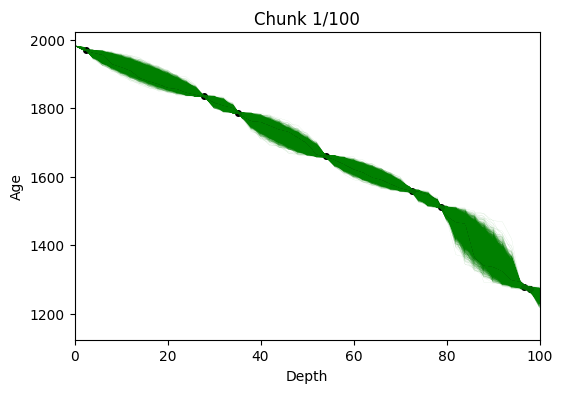

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Example: posterior_samples shape (num_samples, num_depths)
samples = samples[:,:]
chunk_size = config["np"]
num_chunks = len(samples) // chunk_size

# Precompute cumulative sums and offsets
cumulative_sums = np.cumsum(samples, axis=1) * data["dc"]
zeros = np.zeros((samples.shape[0], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
model_ages = data["th"] - age_offsets

mean_model_age = model_ages.mean(axis=0)

# Split samples into chunks
chunks = [
    model_ages[i*chunk_size : (i+1)*chunk_size, :]
    for i in range(num_chunks)
]

print(chunks)

# Add remainder if not divisible
remainder = len(samples) % num_chunks
if remainder > 0:
    chunks.append(model_ages[-remainder:, :])
num_frames = len(chunks)

# Set up figure
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, np.max(data["cs"]))
ax.set_xlabel("Depth")
ax.set_ylabel("Age")

# Plot static data once
ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
ax.plot(data["d18od"], data["d18ota"], color='k', linewidth=0.5)

# Store line objects for each chunk
lines = []

def update(frame):
    # Clear previous chunk lines
    for ln in lines:
        ln.remove()
    lines.clear()

    # Plot all samples in the current chunk
    chunk = chunks[frame]
    for j in range(chunk.shape[0]):
        ln, = ax.plot(
            data["cs"],
            chunk[j, :],
            color='green',
            alpha=0.3,
            linewidth=0.1,
        )
        lines.append(ln)

    ax.set_title(f"Chunk {frame+1}/{num_frames}")
    return lines

anim = FuncAnimation(fig, update, frames=num_frames, interval=1000, blit=False)
anim.save(f"output/sd_{config["sd"]}/{hash}/age_depth.gif", writer="pillow", dpi=150)


In [17]:
# cumulative_sums = np.cumsum(c14_samples[:,:], axis=1) * data["dc"]
# zeros = np.zeros((c14_samples[:,:].shape[0], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)

# model_ages = data["th"] - age_offsets

# mean_model_age = model_ages.mean(axis=(0))

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(c14_samples[:,0])
# lines = np.stack(
#     [np.column_stack((data["cs"], model_ages[j])) for j in range(num_samples)]
# )

# lc = LineCollection(
#     lines,
#     colors="green",
#     linewidths=0.05,
#     alpha=0.05
# )
# ax.add_collection(lc)
# ax.autoscale()
# # for i, c in enumerate(config["cs"]):
# #     ax.axvline(x=c, color='k', linestyle='--')

# ax.set_xlim(0, np.max(data["cs"]))
# plt.plot(data["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{c14_output_dir}/c14_samples.jpg")
# plt.show()



In [18]:
# from matplotlib import colors

# chain = -1
# X = c14_posterior_samples[10000:, :].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     # if i ==25: 
#     #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1)
#     # else:
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'purple', linewidth=3, alpha = 0.2, label = r"$A_1(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.savefig(f"{c14_output_dir}/resampled_no_mean_{chain}.jpg")
# plt.show()

# del A, C
# gc.collect()


In [19]:
# flattened = np.load(r"C:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_c14_normal\output\68831df8d5\samples.npy")[0, :, :]
# from matplotlib import colors

# chain = -1
# X = flattened[1000:, :].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     # if i ==25: 
#     #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1)
#     # else:
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'purple', linewidth=3, alpha = 0.2, label = r"$A_1(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# # plt.savefig(f"{c14_output_dir}/resampled_no_mean_{chain}.jpg")
# plt.show()

# del A, C, X, flattened
# gc.collect()


In [20]:
# # flattened = np.load(r"C:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_c14_normal\output\68831df8d5\samples.npy")[0, :, :]
# from matplotlib import colors

# chain = -1
# X = samples[:, :].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     # if i ==25: 
#     #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1)
#     # else:
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'purple', linewidth=3, alpha = 0.2, label = r"$A_1(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# # plt.savefig(f"{c14_output_dir}/resampled_no_mean_{chain}.jpg")
# plt.show()

# del A, C
# gc.collect()


In [16]:
print(len(posterior_samples))

62863


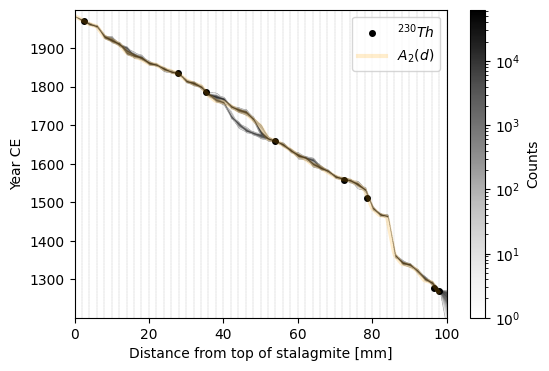

3900

In [17]:
# flattened = np.load(r"C:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_c14_normal\output\68831df8d5\samples.npy")[0, :, :]
from matplotlib import colors

chain = -1
X = posterior_samples[:, :].T
D, N = X.shape

# Depth grid (0:2:2*D)'
depth = np.arange(0, 2 * D + 1, 2)

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 1
t_edges = np.arange(1200, 2000 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, 2 * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, depth, norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    # if i ==25: 
    #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1)
    # else:
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["d18od"], data["d18ota"], color = 'orange', linewidth=3, alpha = 0.2, label = r"$A_2(d)$")

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Counts")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean_{chain}.jpg")
plt.show()

del A, C
gc.collect()


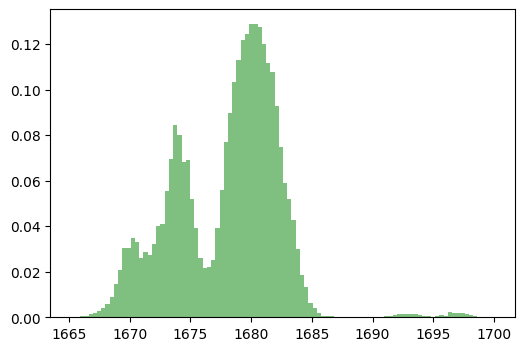

In [18]:
index = 25
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(posterior_samples[:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values[:], bins = 100, color = "green", label = f"chain {1}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

In [24]:
# CV_values = data["th"] - data["dc"] * np.sum(posterior_samples[:, :index], axis = 1)
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.hist(CV_values[:], bins = 100, color = "green", label = f"chain {i}", alpha = 0.5, density = True)
# plt.savefig(f"{output_dir}/resamp_samples_along_depth_{interesting_depth}.jpg")
# plt.show()

In [25]:
# cumulative_sums = np.cumsum(posterior_samples[::10,:], axis=1) * config["delta_c"]
# zeros = np.zeros((posterior_samples[::10,:].shape[0], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)

# model_ages = data["theta"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(posterior_samples[::10,0])

# lines = np.stack(
#     [np.column_stack((config["cs"], model_ages[j])) for j in range(num_samples)]
# )

# lc = LineCollection(
#     lines,
#     colors="green",
#     linewidths=0.05,
#     alpha=0.05
# )
# ax.add_collection(lc)
# ax.autoscale()
# # for j in range(num_samples):
# #     ax.plot(
# #         config["cs"],
# #         model_ages[j, :],
# #         color='green',
# #         alpha=0.3,
# #         linewidth=0.1,
# #     )
# for i, c in enumerate(config["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.set_xlim(0, np.max(config["cs"]))
# plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
# plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/resamp_samples.jpg")
# plt.show()

# del lines, lc
# gc.collect()


In [26]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import colors

# X = posterior_samples.T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.zeros((1, N)),
#     data["theta"] - np.cumsum(X, axis=0)
# ])

# age_mean = np.mean(age, axis = 1)
# norm_age = age- age_mean.reshape(51, 1)

# dt = 0.1
# t_edges = np.arange(-20, 20 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# C = np.full((Z, T), np.nan)

# for i in range(Z):
#     print("hi")
#     idx = z[i] / 2
#     low = int(np.floor(idx))
#     high = int(np.ceil(idx))
#     w = idx - low

#     a = (1 - w) * norm_age[low, :] + w * norm_age[high, :]
#     C[i, :], _ = np.histogram(a, bins=t_edges)

# print("plot")
# plt.figure(1, figsize=(10, 10), dpi=100)
# plt.clf()

# sub = [0.10, 0.10, 0.80, 0.80]
# plt.rcParams.update({
#     'font.size': 11,
#     'axes.labelsize': 11,
#     'xtick.labelsize': 11,
#     'ytick.labelsize': 11
# })

# plt.set_cmap(plt.cm.Oranges)

# print(np.nanmax(C))

# ax = plt.axes(sub)
# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.colorbar(im)
# plt.savefig(f"{output_dir}/resamp_samples_no_mean.jpg")
# plt.show()
